In [1]:
import os
import random
import shutil
import cv2
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter
from ultralytics import YOLO
from tqdm import tqdm

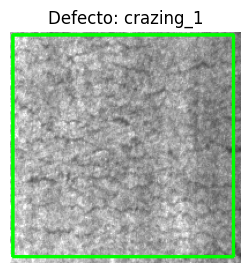

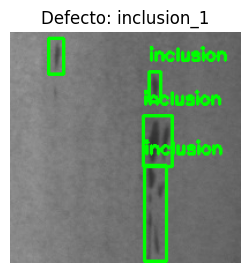

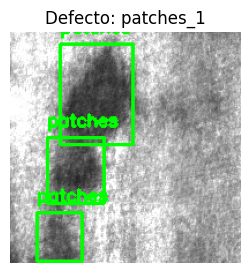

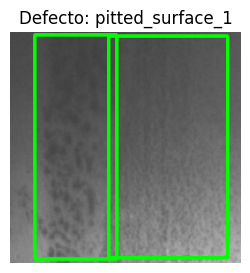

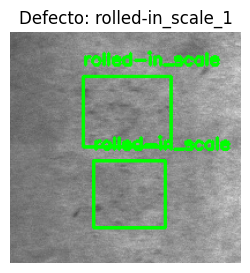

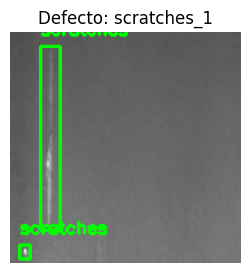

In [2]:
# Rutas (usamos r"" para evitar líos con las barras de Windows)
img_dir = r"../data/raw/IMAGES"
ann_dir = r"../data/raw/ANNOTATIONS"

def plot_defect(img_name):
    # 1. Cargar imagen
    img_path = os.path.join(img_dir, img_name + ".jpg")
    img = cv2.imread(img_path)
    
    # 2. Leer XML (Anotaciones)
    xml_path = os.path.join(ann_dir, img_name + ".xml")
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # 3. Dibujar cada caja de defecto encontrada
    for obj in root.findall('object'):
        label = obj.find('name').text
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        
        # Dibujar rectángulo (Verde, grosor 2)
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        cv2.putText(img, label, (xmin, ymin-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"Defecto: {img_name}")
    plt.axis('off')
    plt.show()

# Probamos con uno de cada (puedes cambiar los nombres)
ejemplos = ["crazing_1", "inclusion_1", "patches_1", "pitted_surface_1", "rolled-in_scale_1", "scratches_1"]
for ej in ejemplos:
    try:
        plot_defect(ej)
    except:
        print(f"No se pudo cargar {ej}, verifica el nombre exacto del archivo.")

In [3]:
# 1. Configuración de rutas
raw_img_dir = Path(r"../data/raw/IMAGES")
raw_ann_dir = Path(r"../data/raw/ANNOTATIONS")
base_data_dir = Path(r"../data")

# 2. Crear carpetas de destino (Añadimos 'test')
for split in ['train', 'val', 'test']:
    (base_data_dir / split / 'images').mkdir(parents=True, exist_ok=True)
    (base_data_dir / split / 'annotations').mkdir(parents=True, exist_ok=True)

# 3. Obtener lista de archivos y mezclar
all_images = [f.stem for f in raw_img_dir.glob("*.jpg")]
random.seed(42) 
random.shuffle(all_images)

# 4. Calcular los puntos de corte para 80% - 10% - 10%
total = len(all_images)
train_end = int(total * 0.80)            # Fin del 80%
val_end = train_end + int(total * 0.10)  # Fin del siguiente 10%

train_list = all_images[:train_end]      # 0% al 80%
val_list = all_images[train_end:val_end] # 80% al 90%
test_list = all_images[val_end:]         # 90% al 100%

def copy_files(file_list, target_split):
    count = 0
    for name in file_list:
        # Rutas de origen
        src_img = raw_img_dir / f"{name}.jpg"
        src_ann = raw_ann_dir / f"{name}.xml"
        
        # Rutas de destino
        dst_img = base_data_dir / target_split / 'images' / f"{name}.jpg"
        dst_ann = base_data_dir / target_split / 'annotations' / f"{name}.xml"
        
        # Copiar archivos
        if src_img.exists() and src_ann.exists():
            shutil.copy(src_img, dst_img)
            shutil.copy(src_ann, dst_ann)
            count += 1
    return count

# 5. Ejecutar el movimiento
print(f"Iniciando copia de archivos (80/10/10)...")
train_count = copy_files(train_list, 'train')
val_count = copy_files(val_list, 'val')
test_count = copy_files(test_list, 'test')

print(f"\n--- PROCESO FINALIZADO ---")
print(f"📦 Imágenes en TRAIN: {train_count} (80%)")
print(f"🧪 Imágenes en VAL:   {val_count} (10%)")
print(f"🔒 Imágenes en TEST:  {test_count} (10%)")
print(f"Total procesado: {train_count + val_count + test_count}")

Iniciando copia de archivos (80/10/10)...

--- PROCESO FINALIZADO ---
📦 Imágenes en TRAIN: 1440 (80%)
🧪 Imágenes en VAL:   180 (10%)
🔒 Imágenes en TEST:  180 (10%)
Total procesado: 1800


In [4]:
classes = ["crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"]

In [5]:
def convert_box(size, box):
    # size: (width, height), box: (xmin, xmax, ymin, ymax)
    dw = 1. / size[0]
    dh = 1. / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    # Normalizamos multiplicando por el inverso del tamaño
    return (x * dw, y * dh, w * dw, h * dh)

def process_labels(split_name):
    ann_path = Path(f"../data/{split_name}/annotations")
    labels_path = Path(f"../data/{split_name}/labels") # Carpeta nueva para YOLO
    labels_path.mkdir(parents=True, exist_ok=True)
    
    count = 0
    for xml_file in ann_path.glob("*.xml"):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        # Obtener dimensiones de la imagen
        size = root.find('size')
        w = int(size.find('width').text)
        h = int(size.find('height').text)
        
        # Crear archivo .txt con el mismo nombre
        txt_file = labels_path / (xml_file.stem + ".txt")
        
        with open(txt_file, 'w') as f:
            for obj in root.findall('object'):
                cls_name = obj.find('name').text
                if cls_name not in classes: continue
                cls_id = classes.index(cls_name)
                
                xmlbox = obj.find('bndbox')
                b = (float(xmlbox.find('xmin').text), float(xmlbox.find('xmax').text), 
                     float(xmlbox.find('ymin').text), float(xmlbox.find('ymax').text))
                
                # Convertir a formato YOLO (clase x_center y_center width height)
                bb = convert_box((w, h), b)
                f.write(f"{cls_id} {' '.join([f'{a:.6f}' for a in bb])}\n")
        count += 1
    return count

# Ejecutar para ambos splits
print("Convirtiendo XML a TXT (formato YOLO)...")
train_txt = process_labels('train')
val_txt = process_labels('val')
test_txt = process_labels('test')
print(f"Hecho. Creados {train_txt} archivos en train, {val_txt} en val y {test_txt} en test.")

Convirtiendo XML a TXT (formato YOLO)...
Hecho. Creados 1440 archivos en train, 180 en val y 180 en test.


In [6]:
# 1. Cargamos el modelo YOLOv8 pequeño (yolov8n.pt) 
# Es rápido y perfecto para empezar con el dataset NEU
model = YOLO('yolov8s.pt') 

# 2. Entrenamos el modelo
results = model.train(
    data='../dataset_config.yaml',
    epochs=100,
    imgsz=448,          # Volvemos a 448 porque es tu "punto dulce" de velocidad/éxito
    batch=8,
    optimizer='AdamW',
    # --- CAMBIOS ESTRATÉGICOS ---
    close_mosaic=20,    # Apagamos el mosaico antes (en la época 80) para que limpie el ruido
    warmup_epochs=5,    # Entrenamiento muy suave al principio para no sesgarse
    overlap_mask=True,  # Mejor manejo de cajas solapadas
    box=7.5,            # Le damos más peso a que el cuadro sea exacto (Box Loss)
    cls=1.0,            # Mantenemos peso en la clasificación
    
    name='TFM_Steel_S_448_Tuned',
    device=0
)


New https://pypi.org/project/ultralytics/8.4.27 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
engine\trainer: task=detect, mode=train, model=yolov8s.pt, data=../dataset_config.yaml, epochs=100, time=None, patience=50, batch=8, imgsz=448, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=TFM_Steel_S_448_Tuned, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=20, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, 

train: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\train\labels.cache... 1440 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1440/1440 [00:00<?, ?it/s]

train: WARNING ⚠️ C:\Users\Usuario\Desktop\TFM_NEU\data\train\images\crazing_120.jpg: 1 duplicate labels removed
train: WARNING ⚠️ C:\Users\Usuario\Desktop\TFM_NEU\data\train\images\inclusion_62.jpg: 1 duplicate labels removed
train: WARNING ⚠️ C:\Users\Usuario\Desktop\TFM_NEU\data\train\images\patches_198.jpg: 1 duplicate labels removed



val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\val\labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]


Plotting labels to runs\detect\TFM_Steel_S_448_Tuned\labels.jpg... 
optimizer: AdamW(lr=0.01, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

    100/100      1.37G      1.214      1.928      1.432         20        448: 100%|██████████| 180/180 [00:16<00:00, 10.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:01<00:00,  9.65it/s]

                   all        180        396      0.665      0.733      0.755      0.441



100 epochs completed in 0.538 hours.
Optimizer stripped from runs\detect\TFM_Steel_S_448_Tuned\weights\last.pt, 22.5MB
Optimizer stripped from runs\detect\TFM_Steel_S_448_Tuned\weights\best.pt, 22.5MB

Validating runs\detect\TFM_Steel_S_448_Tuned\weights\best.pt...
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 11127906 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:01<00:00,  6.46it/s]


                   all        180        396      0.662      0.734      0.754      0.442
               crazing        180         66      0.454       0.29       0.37      0.144
             inclusion        180        106      0.717       0.83      0.773      0.428
               patches        180         69       0.78      0.957      0.953      0.632
        pitted_surface        180         43      0.757      0.767       0.85      0.525
       rolled-in_scale        180         57       0.51      0.632      0.649      0.331
             scratches        180         55      0.757      0.927      0.927      0.589
Speed: 0.2ms preprocess, 3.0ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs\detect\TFM_Steel_S_448_Tuned


In [14]:
# CARGAMOS TU MEJOR MODELO (el Tuned de 0.778)
model = YOLO('C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/TFM_Steel_S_448_Tuned/weights/best.pt')

# LANZAMOS EL "LAST DANCE"
results = model.train(
    data='../dataset_config.yaml',
    epochs=50,
    imgsz=448,
    batch=8,
    lr0=0.0001,
    copy_paste=0.4,
    augment=True,
    degrees=20.0,
    cls=2.5,
    name='TFM_Steel_S_THE_LAST_DANCE',
    device=0
)

New https://pypi.org/project/ultralytics/8.4.27 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
engine\trainer: task=detect, mode=train, model=C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/TFM_Steel_S_448_Tuned/weights/best.pt, data=../dataset_config.yaml, epochs=50, time=None, patience=50, batch=8, imgsz=448, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=TFM_Steel_S_THE_LAST_DANCE, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=Fal

train: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\train\labels.cache... 1440 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1440/1440 [00:00<?, ?it/s]

train: WARNING ⚠️ C:\Users\Usuario\Desktop\TFM_NEU\data\train\images\crazing_120.jpg: 1 duplicate labels removed
train: WARNING ⚠️ C:\Users\Usuario\Desktop\TFM_NEU\data\train\images\inclusion_62.jpg: 1 duplicate labels removed
train: WARNING ⚠️ C:\Users\Usuario\Desktop\TFM_NEU\data\train\images\patches_198.jpg: 1 duplicate labels removed



val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\val\labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]


Plotting labels to runs\detect\TFM_Steel_S_THE_LAST_DANCE\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.0001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      50/50      1.34G      1.293       5.09      1.607         17        448: 100%|██████████| 180/180 [00:16<00:00, 10.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:01<00:00, 10.68it/s]

                   all        180        396      0.683      0.734      0.741      0.359



50 epochs completed in 0.290 hours.
Optimizer stripped from runs\detect\TFM_Steel_S_THE_LAST_DANCE\weights\last.pt, 22.5MB
Optimizer stripped from runs\detect\TFM_Steel_S_THE_LAST_DANCE\weights\best.pt, 22.5MB

Validating runs\detect\TFM_Steel_S_THE_LAST_DANCE\weights\best.pt...
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 11127906 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:03<00:00,  3.30it/s]


                   all        180        396      0.691      0.708      0.758      0.382
               crazing        180         66      0.451      0.197      0.352      0.143
             inclusion        180        106      0.638      0.783      0.761      0.378
               patches        180         69      0.854      0.933      0.959      0.585
        pitted_surface        180         43      0.865      0.814      0.898      0.507
       rolled-in_scale        180         57      0.567      0.614      0.664      0.285
             scratches        180         55      0.772      0.909      0.916       0.39
Speed: 0.3ms preprocess, 14.6ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs\detect\TFM_Steel_S_THE_LAST_DANCE


In [2]:
# 1. Cargamos tu modelo campeón (el de 0.778)
model_path = 'C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/TFM_Steel_S_448_Tuned/weights/best.pt'
model = YOLO(model_path)

# 2. LANZAMOS EL ENTRENAMIENTO CON FOCAL LOSS "FORZADA"
# es subir el peso 'cls' que es el que Focal Loss multiplica.

results = model.train(
    data='../dataset_config.yaml',
    epochs=60,
    imgsz=448,
    batch=40,
    lr0=0.0001,
    optimizer='AdamW',
    
    # --- CONFIGURACIÓN FOCAL LOSS ---    
    cls=4.0,             # Aumentamos el peso de clasificación para ayudar a FL
    
    # Quitamos copy_paste y aumentos agresivos para ver el efecto puro de FL
    augment=True,        
    degrees=15.0,        
    label_smoothing=0.05, 
    
    name='TFM_Steel_S_FOCAL_LOSS_ONLY',
    device=0
)

print("🔥 Entrenando con el enfoque en Focal Loss...")

New https://pypi.org/project/ultralytics/8.4.29 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
engine\trainer: task=detect, mode=train, model=C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/TFM_Steel_S_448_Tuned/weights/best.pt, data=../dataset_config.yaml, epochs=60, time=None, patience=50, batch=40, imgsz=448, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=TFM_Steel_S_FOCAL_LOSS_ONLY3, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize

train: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\train\labels.cache... 1440 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1440/1440 [00:00<?, ?it/s]

train: WARNING ⚠️ C:\Users\Usuario\Desktop\TFM_NEU\data\train\images\crazing_120.jpg: 1 duplicate labels removed
train: WARNING ⚠️ C:\Users\Usuario\Desktop\TFM_NEU\data\train\images\inclusion_62.jpg: 1 duplicate labels removed
train: WARNING ⚠️ C:\Users\Usuario\Desktop\TFM_NEU\data\train\images\patches_198.jpg: 1 duplicate labels removed



val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\val\labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]


Plotting labels to runs\detect\TFM_Steel_S_FOCAL_LOSS_ONLY3\labels.jpg... 
optimizer: AdamW(lr=0.0001, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.000625), 63 bias(decay=0.0)
60 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      60/60      4.75G      1.342      8.649      1.614         84        448: 100%|██████████| 36/36 [00:08<00:00,  4.49it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.50it/s]

                   all        180        396      0.729      0.695      0.753      0.348



60 epochs completed in 0.183 hours.
Optimizer stripped from runs\detect\TFM_Steel_S_FOCAL_LOSS_ONLY3\weights\last.pt, 22.5MB
Optimizer stripped from runs\detect\TFM_Steel_S_FOCAL_LOSS_ONLY3\weights\best.pt, 22.5MB

Validating runs\detect\TFM_Steel_S_FOCAL_LOSS_ONLY3\weights\best.pt...
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 11127906 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:02<00:00,  1.11it/s]


                   all        180        396      0.604      0.712      0.735      0.347
               crazing        180         66      0.429      0.212      0.377      0.134
             inclusion        180        106      0.572      0.807      0.743      0.322
               patches        180         69      0.731      0.971      0.948      0.537
        pitted_surface        180         43      0.701      0.814       0.87      0.505
       rolled-in_scale        180         57      0.553      0.614       0.65      0.287
             scratches        180         55      0.639      0.855      0.825        0.3
Speed: 0.1ms preprocess, 9.4ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs\detect\TFM_Steel_S_FOCAL_LOSS_ONLY3
🔥 Entrenando con el enfoque en Focal Loss...


In [7]:
model_path = 'C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/TFM_Steel_S_448_Tuned/weights/best.pt'
model = YOLO(model_path)

# 2. Validación LIMPIA (sin Hybrid Labels)
print("🧼 Iniciando validación limpia para resultados reales...")
metrics = model.val(
    data='C:/Users/Usuario/Desktop/TFM_NEU/dataset_config.yaml',
    split='test',      
    imgsz=448,
    conf=0.15,         
    iou=0.40,
    save=True,         # Guarda las fotos con predicciones
    plots=True,        # Genera las gráficas (Confusion Matrix, etc.)
    save_hybrid=False, # <-- IMPORTANTE: Lo ponemos en False para que no use las etiquetas reales
    name='tunned_pro_ultra'
)

print("-" * 30)
print(f"📊 mAP50 REAL: {metrics.box.map50:.4f}")

🧼 Iniciando validación limpia para resultados reales...
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 11127906 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\test\labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:01<00:00,  6.36it/s]


                   all        180        442      0.714      0.741      0.773      0.463
               crazing        180         74      0.525      0.392      0.436      0.202
             inclusion        180        113      0.677      0.743      0.742      0.422
               patches        180         80      0.839      0.938      0.952      0.667
        pitted_surface        180         33      0.765      0.788      0.845      0.574
       rolled-in_scale        180         75       0.63      0.707      0.727      0.367
             scratches        180         67      0.846      0.881      0.932      0.543
Speed: 0.4ms preprocess, 4.7ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs\detect\tunned_pro_ultra2
------------------------------
📊 mAP50 REAL: 0.7725


In [ ]:
# 1. Definimos las rutas de tus dos "campeones"
path_s = 'C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/TFM_Steel_S_448_Tuned/weights/best.pt'
path_n = 'C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/tfm_steel_aimgsz_448_mixup_0-52/weights/best.pt'

# 2. Cargamos los modelos en una lista para el Ensemble
# YOLOv8 permite pasar una lista de modelos a la clase YOLO para validación conjunta
try:
    print("🧠 Cargando modelos para el Ensemble...")
    # Cargamos el primer modelo y le "añadimos" el segundo en la validación
    model = YOLO(path_s)
    
    # 3. Lanzamos la validación conjunta
    # Al pasar una lista en 'model' dentro de val, forzamos el ensemble
    print("🚀 Iniciando Ensemble (S + N)...")
    results = model.val(
        model=[path_s, path_n], # Aquí pasamos la lista de pesos
        data='C:/Users/Usuario/Desktop/TFM_NEU/dataset_config.yaml', # Usa tu YAML original
        imgsz=448,
        conf=0.20,
        iou=0.60,
        split='test' # O 'val', según lo que quieras medir
    )
    
    print("✅ ¡Ensemble completado!")
    
except Exception as e:
    print(f"❌ Error al ejecutar el ensemble: {e}")

🧠 Cargando modelos para el Ensemble...
🚀 Iniciando Ensemble (S + N)...
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 11127906 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\test\labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:01<00:00,  6.71it/s]


                   all        180        442      0.754      0.685      0.762      0.458
               crazing        180         74      0.594       0.23      0.406      0.197
             inclusion        180        113      0.767      0.698      0.744      0.428
               patches        180         80      0.861      0.938      0.962      0.666
        pitted_surface        180         33        0.7      0.758       0.81      0.553
       rolled-in_scale        180         75      0.681      0.625      0.717      0.362
             scratches        180         67       0.92      0.862      0.932      0.543
Speed: 0.3ms preprocess, 4.0ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs\detect\val38
✅ ¡Ensemble completado!


In [12]:
# 1. Definimos las rutas de tus dos "campeones"
path_s = 'C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/TFM_Steel_S_448_Tuned/weights/best.pt'
path_n = 'C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/tfm_steel_aimgsz_448_mixup_0-52/weights/best.pt'

# 2. Cargamos los modelos en una lista para el Ensemble
# YOLOv8 permite pasar una lista de modelos a la clase YOLO para validación conjunta
try:
    print("🧠 Cargando modelos para el Ensemble...")
    # Cargamos el primer modelo y le "añadimos" el segundo en la validación
    model = YOLO(path_s)
    
    # 3. Lanzamos la validación conjunta
    # Al pasar una lista en 'model' dentro de val, forzamos el ensemble
    print("🚀 Iniciando Ensemble (S + N)...")
    results = model.val(
        model=[path_s, path_n], # Aquí pasamos la lista de pesos
        data='C:/Users/Usuario/Desktop/TFM_NEU/dataset_config.yaml', # Usa tu YAML original
        imgsz=448,
        conf=0.10,
        iou=0.45,
        split='test' # O 'val', según lo que quieras medir
    )
    
    print("✅ ¡Ensemble completado!")
    
except Exception as e:
    print(f"❌ Error al ejecutar el ensemble: {e}")

🧠 Cargando modelos para el Ensemble...
🚀 Iniciando Ensemble (S + N)...
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 11127906 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\test\labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:01<00:00,  8.26it/s]


                   all        180        442       0.73      0.716      0.779      0.459
               crazing        180         74      0.503       0.27       0.44      0.197
             inclusion        180        113      0.729      0.726      0.746      0.421
               patches        180         80      0.846      0.938      0.957      0.668
        pitted_surface        180         33      0.796      0.818      0.867       0.57
       rolled-in_scale        180         75      0.619      0.667      0.732      0.361
             scratches        180         67      0.888      0.881      0.935      0.538
Speed: 0.2ms preprocess, 3.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs\detect\val39
✅ ¡Ensemble completado!


In [5]:
# 1. Definimos las rutas de tus dos "campeones"
path_s = 'C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/TFM_Steel_S_448_Tuned/weights/best.pt'
path_n = 'C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/tfm_steel_aimgsz_448_mixup_0-52/weights/best.pt'

# 2. Cargamos los modelos en una lista para el Ensemble
# YOLOv8 permite pasar una lista de modelos a la clase YOLO para validación conjunta
try:
    print("🧠 Cargando modelos para el Ensemble...")
    # Cargamos el primer modelo y le "añadimos" el segundo en la validación
    model = YOLO(path_s)
    
    # 3. Lanzamos la validación conjunta
    # Al pasar una lista en 'model' dentro de val, forzamos el ensemble
    print("🚀 Iniciando Ensemble (S + N)...")
    results = model.val(
        model=[path_s, path_n], # Aquí pasamos la lista de pesos
        data='C:/Users/Usuario/Desktop/TFM_NEU/dataset_config.yaml', # Usa tu YAML original
        imgsz=448,
        conf=0.30,
        iou=0.40,
        split='test' # O 'val', según lo que quieras medir
    )
    
    print("✅ ¡Ensemble completado!")
    
except Exception as e:
    print(f"❌ Error al ejecutar el ensemble: {e}")

🧠 Cargando modelos para el Ensemble...
🚀 Iniciando Ensemble (S + N)...
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 11127906 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\test\labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:01<00:00,  6.60it/s]


                   all        180        442      0.779      0.691      0.755      0.467
               crazing        180         74      0.559       0.23      0.374      0.196
             inclusion        180        113      0.755      0.699      0.742      0.431
               patches        180         80      0.889      0.938      0.955      0.672
        pitted_surface        180         33      0.838      0.785      0.844       0.59
       rolled-in_scale        180         75      0.696      0.627      0.687      0.362
             scratches        180         67      0.936      0.869      0.926      0.549
Speed: 0.4ms preprocess, 3.7ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs\detect\val51
✅ ¡Ensemble completado!


In [5]:
# 1. Definimos las rutas de tus dos "campeones"
path_s = 'C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/TFM_Steel_S_448_Tuned/weights/best.pt'
path_n = 'C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/tfm_steel_aimgsz_448_mixup_0-52/weights/best.pt'

# 2. Cargamos los modelos en una lista para el Ensemble
# YOLOv8 permite pasar una lista de modelos a la clase YOLO para validación conjunta
try:
    print("🧠 Cargando modelos para el Ensemble...")
    # Cargamos el primer modelo y le "añadimos" el segundo en la validación
    model = YOLO(path_s)
    
    # 3. Lanzamos la validación conjunta
    # Al pasar una lista en 'model' dentro de val, forzamos el ensemble
    print("🚀 Iniciando Ensemble (S + N)...")
    results = model.val(
        model=[path_s, path_n], # Aquí pasamos la lista de pesos
        data='C:/Users/Usuario/Desktop/TFM_NEU/dataset_config.yaml', # Usa tu YAML original
        imgsz=448,
        conf=0.8,
        iou=0.1,
        split='test' # O 'val', según lo que quieras medir
    )
    
    print("✅ ¡Ensemble completado!")
    
except Exception as e:
    print(f"❌ Error al ejecutar el ensemble: {e}")

🧠 Cargando modelos para el Ensemble...
🚀 Iniciando Ensemble (S + N)...
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 11127906 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\test\labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:01<00:00,  9.36it/s]


                   all        180        442      0.795      0.169      0.482      0.359
               crazing        180         74          0          0          0          0
             inclusion        180        113      0.769     0.0885       0.43      0.306
               patches        180         80          1      0.438      0.719      0.549
        pitted_surface        180         33          1      0.121      0.561      0.517
       rolled-in_scale        180         75          1        0.2        0.6       0.36
             scratches        180         67          1      0.164      0.582       0.42
Speed: 0.3ms preprocess, 2.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs\detect\val61
✅ ¡Ensemble completado!


In [3]:
# Evaluar el modelo con las fotos de Test
metrics = model.val(split='test') 
print(f"mAP50 final en TEST: {metrics.box.map50}")

Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 11127906 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\test\labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:03<00:00,  1.34it/s]


                   all        180        442      0.718      0.642      0.731      0.341
               crazing        180         74      0.705      0.162      0.387      0.165
             inclusion        180        113      0.683      0.708      0.751      0.303
               patches        180         80      0.789      0.875      0.929      0.494
        pitted_surface        180         33      0.701      0.727      0.813      0.476
       rolled-in_scale        180         75       0.68      0.627      0.736      0.308
             scratches        180         67      0.748      0.754      0.771      0.297
Speed: 0.9ms preprocess, 15.0ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs\detect\TFM_Steel_S_FOCAL_LOSS_ONLY32
mAP50 final en TEST: 0.7310460930029533


In [8]:
# 1. Configuración de rutas
model_path = r'runs/detect/tfm_steel_v118/weights/best.pt'
model = YOLO(model_path)
test_images_dir = Path('../data/test/images')
test_labels_dir = Path('../data/test/labels')

# 2. Selección aleatoria de imagen y su etiqueta .txt
img_path = random.choice(list(test_images_dir.glob('*.jpg')))
label_path = test_labels_dir / f"{img_path.stem}.txt"

class_names = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

# 3. PREDICCIÓN IA (Izquierda)
results = model(str(img_path))[0]
img_ia = cv2.cvtColor(results.plot(), cv2.COLOR_BGR2RGB)

print(f"\n--- ANÁLISIS DE IMAGEN: {img_path.name} ---")
print(f"🤖 IA ha detectado {len(results.boxes)} etiquetas:")
for i, box in enumerate(results.boxes):
    coords = box.xyxy[0].tolist()
    conf = box.conf[0]
    cls = int(box.cls[0])
    name = model.names[cls]
    print(f"   [{i+1}] {name} (Conf: {conf:.2f}) -> Coords: [xmin:{int(coords[0])}, ymin:{int(coords[1])}, xmax:{int(coords[2])}, ymax:{int(coords[3])}]")

# 4. ORIGINAL DESDE TXT (Derecha)
img_original = cv2.imread(str(img_path))
h, w, _ = img_original.shape
original_count = 0

print(f"\n📄 ORIGINAL (txt) tiene etiquetas registradas:")
if label_path.exists():
    with open(label_path, 'r') as f:
        lines = f.readlines()
        original_count = len(lines)
        for i, line in enumerate(lines):
            parts = line.split()
            cls_id = int(parts[0])
            cls, x_c, y_c, wb, hb = map(float, line.split())

            try:
                real_name = class_names[cls_id]
            except IndexError:
                real_name = f"ID Desconocido: {cls_id}"
            # Conversión de normalizado YOLO a píxeles reales
            x1, y1 = int((x_c - wb/2) * w), int((y_c - hb/2) * h)
            x2, y2 = int((x_c + wb/2) * w), int((y_c + hb/2) * h)
            
            # Dibujar en la imagen
            cv2.rectangle(img_original, (x1, y1), (x2, y2), (255, 255, 255), 2)
            cv2.putText(img_original, f"Org:{int(cls)}", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
            print(f"   [{i+1}] Clase: {real_name} (ID: {cls_id}) -> Coords: [xmin:{x1}, ymin:{y1}, xmax:{x2}, ymax:{y2}]")
else:
    print("   ⚠️ No se encontró archivo de etiquetas original.")

img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

# 5. Visualización Comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
ax1.imshow(img_ia)
ax1.set_title(f"PREDICCIÓN IA ({len(results.boxes)} detecciones)")
ax1.axis('off')

ax2.imshow(img_original)
ax2.set_title(f"ORIGINAL ({original_count} etiquetas)")
ax2.axis('off')

plt.tight_layout()
plt.show()


image 1/1 c:\Users\Usuario\Desktop\TFM_NEU\notebooks\..\data\test\images\pitted_surface_273.jpg: 224x224 1 pitted_surface, 12.0ms
Speed: 20.0ms preprocess, 12.0ms inference, 20.2ms postprocess per image at shape (1, 3, 224, 224)

--- ANÁLISIS DE IMAGEN: pitted_surface_273.jpg ---
🤖 IA ha detectado 1 etiquetas:
   [1] pitted_surface (Conf: 0.68) -> Coords: [xmin:7, ymin:1, xmax:199, ymax:199]

📄 ORIGINAL (txt) tiene etiquetas registradas:
   [1] Clase: pitted_surface (ID: 3) -> Coords: [xmin:55, ymin:16, xmax:198, ymax:200]


<Figure size 1600x800 with 2 Axes>

In [4]:
# Carga el modelo
model = YOLO('C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/TFM_Steel_S_ULTRA_FINAL2/weights/best.pt')

# Ejecuta la validación en el conjunto de TEST
metrics = model.val(
    data='../dataset_config.yaml', 
    split='test',   # <--- Importante: forzamos que mire la carpeta TEST
    imgsz=448,
    batch=1,
    conf=0.10,       # Prueba a bajarlo a 0.15 para ver si sube el mAP
    iou=0.45
)

print(f"mAP50 en Test: {metrics.box.map50:.4f}")

Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 11127906 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\test\labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 180/180 [00:02<00:00, 60.88it/s]


                   all        180        442      0.697      0.657      0.714      0.313
               crazing        180         74      0.608       0.21      0.417      0.139
             inclusion        180        113      0.597       0.69      0.705      0.253
               patches        180         80      0.805      0.912      0.901      0.437
        pitted_surface        180         33      0.808      0.758      0.844      0.485
       rolled-in_scale        180         75      0.622      0.613      0.647       0.29
             scratches        180         67      0.745      0.761      0.771      0.273
Speed: 0.4ms preprocess, 10.4ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs\detect\val25
mAP50 en Test: 0.7140


In [5]:
# Carga el modelo
model = YOLO('C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/TFM_Steel_S_ULTRA_FINAL2/weights/best.pt')

# Ejecuta la validación en el conjunto de TEST
metrics = model.val(
    data='../dataset_config.yaml', 
    split='test',   # <--- Importante: forzamos que mire la carpeta TEST
    imgsz=448,
    batch=1,
    conf=0.15,       # Prueba a bajarlo a 0.15 para ver si sube el mAP
    iou=0.40
)

print(f"mAP50 en Test: {metrics.box.map50:.4f}")

Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 11127906 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\test\labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100%|██████████| 180/180 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 180/180 [00:03<00:00, 58.06it/s]


                   all        180        442        0.7      0.658      0.708      0.312
               crazing        180         74       0.61      0.211      0.401      0.129
             inclusion        180        113      0.597       0.69      0.702      0.256
               patches        180         80      0.805      0.912      0.905      0.445
        pitted_surface        180         33      0.834      0.758      0.823      0.473
       rolled-in_scale        180         75      0.613      0.613       0.64      0.292
             scratches        180         67      0.744      0.761      0.777      0.277
Speed: 0.5ms preprocess, 10.8ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs\detect\val26
mAP50 en Test: 0.7079


In [43]:
# 1. Configuración de Rutas Originales
image_dir = 'C:/Users/Usuario/Desktop/TFM_NEU/data/test/images/'
label_dir = 'C:/Users/Usuario/Desktop/TFM_NEU/data/test/labels/'

# 2. Rutas del Nuevo Dataset Troceado
output_base = 'C:/Users/Usuario/Desktop/TFM_NEU/data/test_sliced/'
out_images = os.path.join(output_base, 'images/')
out_labels = os.path.join(output_base, 'labels/')

os.makedirs(out_images, exist_ok=True)
os.makedirs(out_labels, exist_ok=True)

# Coordenadas de corte (dx, dy) -> Esquina superior izquierda de cada parche
offsets = [
    (0, 0),       # 1. Superior Izquierda
    (192, 0),     # 2. Superior Derecha (448 - 256 = 192)
    (0, 192),     # 3. Inferior Izquierda
    (192, 192)    # 4. Inferior Derecha
]

print("🔪 Troceando Dataset Físicamente (Imágenes y Etiquetas)...")

for img_name in tqdm(os.listdir(image_dir)):
    if not img_name.endswith(('.jpg', '.png', '.jpeg')): continue
    
    # Leer y redimensionar imagen a 448x448
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path)
    if img is None: continue
    img = cv2.resize(img, (448, 448))
    
    # Leer etiquetas originales
    txt_name = img_name.rsplit('.', 1)[0] + '.txt'
    txt_path = os.path.join(label_dir, txt_name)
    
    boxes = []
    if os.path.exists(txt_path):
        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    c_id, cx, cy, w, h = map(float, parts)
                    # Convertir formato YOLO (normalizado) a píxeles absolutos (448x448)
                    x1 = (cx - w/2) * 448
                    y1 = (cy - h/2) * 448
                    x2 = (cx + w/2) * 448
                    y2 = (cy + h/2) * 448
                    boxes.append([int(c_id), x1, y1, x2, y2])
    
    # Generar los 4 recortes
    base_name = img_name.rsplit('.', 1)[0]
    for i, (dx, dy) in enumerate(offsets):
        # 1. Recortar imagen
        patch = img[dy:dy+256, dx:dx+256]
        patch_name = f"{base_name}_slice_{i}.jpg"
        cv2.imwrite(os.path.join(out_images, patch_name), patch)
        
        # 2. Recalcular cajas para este recorte
        patch_labels = []
        for box in boxes:
            c_id, x1, y1, x2, y2 = box
            
            # Trasladar coordenadas al nuevo recorte
            new_x1 = max(0, x1 - dx)
            new_y1 = max(0, y1 - dy)
            new_x2 = min(256, x2 - dx)
            new_y2 = min(256, y2 - dy)
            
            # Si la caja sigue existiendo dentro del recorte (mínimo 2 píxeles de ancho/alto)
            if (new_x2 - new_x1) > 2 and (new_y2 - new_y1) > 2:
                # Volver a convertir a formato YOLO (normalizado a 256x256)
                new_w = (new_x2 - new_x1) / 256.0
                new_h = (new_y2 - new_y1) / 256.0
                new_cx = (new_x1 + new_x2) / 2.0 / 256.0
                new_cy = (new_y1 + new_y2) / 2.0 / 256.0
                
                patch_labels.append(f"{c_id} {new_cx:.6f} {new_cy:.6f} {new_w:.6f} {new_h:.6f}")
        
        # Guardar el nuevo .txt (solo si hay etiquetas en este trozo, si no, YOLO asume que está limpia)
        if patch_labels:
            with open(os.path.join(out_labels, f"{base_name}_slice_{i}.txt"), 'w') as f:
                f.write("\n".join(patch_labels))

# 3. Crear archivo YAML para la validación
yaml_path = os.path.join(output_base, 'sliced_dataset.yaml')
yaml_content = f"""
path: {output_base}
train: images/
val: images/

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches
"""
with open(yaml_path, 'w') as f:
    f.write(yaml_content.strip())

print(f"✅ ¡Dataset Sliced completado! YAML guardado en: {yaml_path}")

🔪 Troceando Dataset Físicamente (Imágenes y Etiquetas)...


100%|██████████| 180/180 [00:00<00:00, 236.76it/s]

✅ ¡Dataset Sliced completado! YAML guardado en: C:/Users/Usuario/Desktop/TFM_NEU/data/test_sliced/sliced_dataset.yaml


In [48]:
# Cargamos el modelo
model_path = 'C:/Users/Usuario/Desktop/TFM_NEU/notebooks/runs/detect/TFM_Steel_S_448_Tuned/weights/best.pt'
model = YOLO(model_path)

# Lanzamos la validación nativa de YOLO sobre el dataset troceado
print("📊 Generando Tabla Oficial de Métricas (Slicing 256px)...")
metrics = model.val(
    data='C:/Users/Usuario/Desktop/TFM_NEU/data/test_sliced/sliced_dataset.yaml',
    imgsz=256,
    batch=1,
    # conf=0.1,# Tu umbral ganador
    # iou=0.8,
    split='val'
)

📊 Generando Tabla Oficial de Métricas (Slicing 256px)...
Ultralytics YOLOv8.1.0 🚀 Python-3.11.15 torch-2.2.1 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8191MiB)
Model summary (fused): 168 layers, 11127906 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning C:\Users\Usuario\Desktop\TFM_NEU\data\test_sliced\labels.cache... 664 images, 56 backgrounds, 0 corrupt: 100%|██████████| 720/720 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 720/720 [01:32<00:00,  7.77it/s]


                   all        720       1138      0.667      0.558        0.6      0.341
               crazing        720        232       0.53      0.164      0.278      0.123
             inclusion        720        247      0.665      0.603      0.625      0.302
               patches        720        170       0.73      0.759      0.775      0.482
        pitted_surface        720        119      0.707      0.628      0.683        0.5
       rolled-in_scale        720        204      0.544      0.456      0.454      0.207
             scratches        720        166      0.825      0.738      0.783      0.431
Speed: 0.4ms preprocess, 123.4ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs\detect\val35


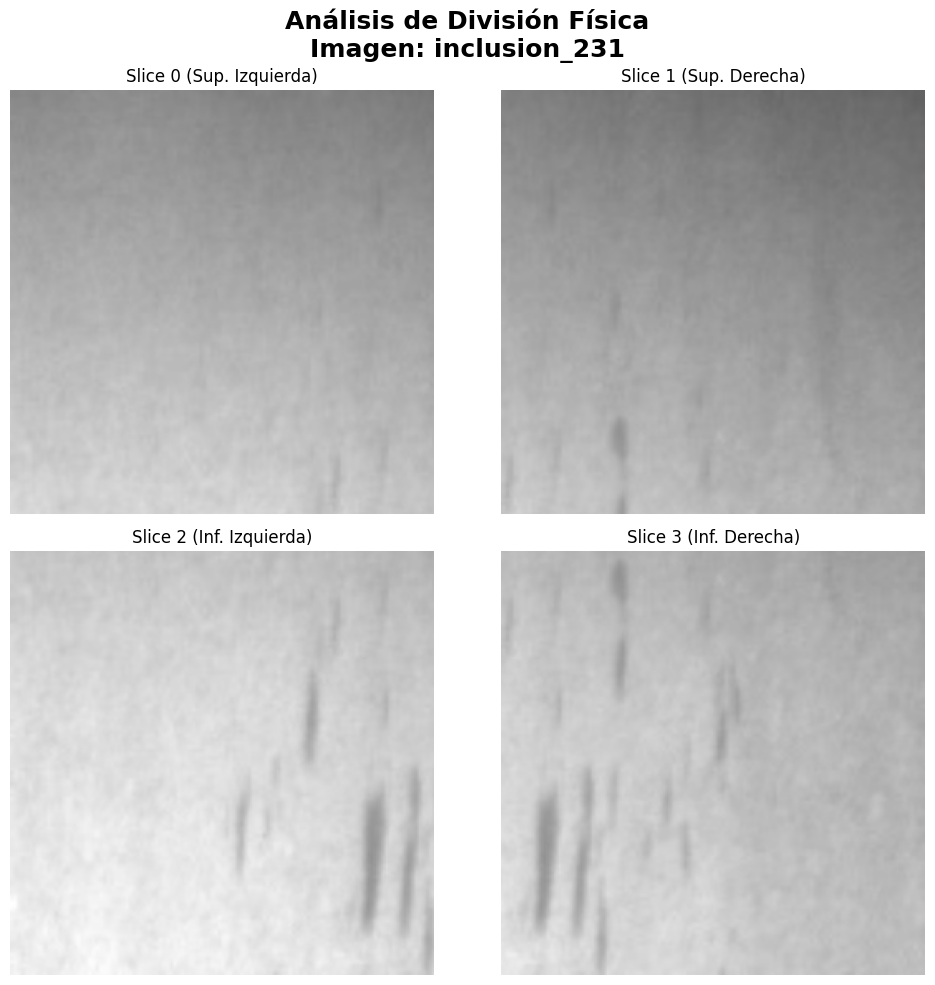

In [46]:
%matplotlib inline

# 1. Ruta donde guardamos físicamente los trozos
sliced_dir = 'C:/Users/Usuario/Desktop/TFM_NEU/data/test_sliced/images/'
base_name = 'inclusion_231' # El nombre base de tu imagen

# 2. Nombres exactos de los 4 archivos (asumiendo que son .jpg)
# Si tu dataset original usaba .png, cambia la extensión aquí abajo
slices = [
    f"{base_name}_slice_0.jpg", # Cuadrante 1: Superior Izquierda
    f"{base_name}_slice_1.jpg", # Cuadrante 2: Superior Derecha
    f"{base_name}_slice_2.jpg", # Cuadrante 3: Inferior Izquierda
    f"{base_name}_slice_3.jpg"  # Cuadrante 4: Inferior Derecha
]

titulos = [
    "Slice 0 (Sup. Izquierda)",
    "Slice 1 (Sup. Derecha)",
    "Slice 2 (Inf. Izquierda)",
    "Slice 3 (Inf. Derecha)"
]

# 3. Preparamos el lienzo 2x2
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle(f"Análisis de División Física\nImagen: {base_name}", fontsize=18, fontweight='bold')

for i, slice_name in enumerate(slices):
    img_path = os.path.join(sliced_dir, slice_name)
    
    # Calculamos la fila (0 o 1) y columna (0 o 1) para la cuadrícula
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    # Comprobamos que el archivo existe
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Para que Matplotlib no cambie los colores
        ax.imshow(img_rgb)
    else:
        # Si da error, te avisa en la propia gráfica
        ax.text(0.5, 0.5, '❌ Archivo no encontrado', ha='center', va='center', fontsize=12)
        print(f"⚠️ Cuidado, no encuentro el archivo: {img_path}")
        
    ax.set_title(titulos[i], fontsize=12)
    ax.axis('off') # Ocultamos la regla de píxeles para que quede limpio

# Ajustamos márgenes y mostramos
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()